This notebook performs a machine learning analysis of the "Students Performance in Exams" dataset, focusing on how demographic factors (such as gender, race/ethnicity, and parental education) influence student performance. The methods used and the steps involved are:

Data loading and preprocessing

Feature engineering

Train/test split

Linear Regression

Logistic Regression

Random Forest

Gradient Boosting

Model evaluation

Feature importance.

## 1. Import Libraries

This cell imports all necessary libraries for data manipulation, machine learning models, and visualization that will be used.

In [23]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Download Dataset

The 'Students Performance in Exams' dataset from KaggleHub is downloaded, making it available for use in the notebook.

In [24]:
import kagglehub
spscientist_students_performance_in_exams_path = kagglehub.dataset_download('spscientist/students-performance-in-exams')

print('Data source import complete.')

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Data source import complete.


## 3. Load Data and Feature Engineering

Here, the dataset is loaded into a pandas DataFrame. New features such as `total_score`, `average_score`, and a binary `pass_fail` variable are created to enhance the analysis.

In [25]:
# Load the dataset

df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')
df.head(5)

# Feature engineering

df["total_score"] = df[["math score", "reading score", "writing score"]].sum(axis=1)
df["average_score"] = df["total_score"] / 3
df["pass_fail"] = np.where(df["average_score"] >= 60, 1, 0)

## 4. Encoding the Categorical Variables

The categorical variables are encoded.

In [26]:
# Encoding the Categorical Variables
df_encoded = df.copy()
label_cols = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]

for col in label_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

## 5. Prepare Data for Regression Modelling

This section prepares the data for regression task.

In [27]:
# Predicting average score by regression

X_reg = df_encoded.drop(["average_score"], axis=1)
y_reg = df_encoded["average_score"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split( X_reg, y_reg, test_size=0.2, random_state=42)

## 6. Prepare Data for Classification Task

Similar to the regression task, this section prepares the data for a classification task.

In [28]:
# Predicting pass and fail by classification

X_clf = df_encoded.drop(["pass_fail"], axis=1)
y_clf = df_encoded["pass_fail"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

## 7. Linear Regression Model

This cell trains a Linear Regression model using the prepared regression data.

In [29]:
# Linear Regression Model

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = lin_reg.predict(X_test_reg)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("Linear Regression R2:", r2_score(y_test_reg, y_pred_reg))

Linear Regression RMSE: 1.3080670102958696e-14
Linear Regression R2: 1.0


## 8. Logistic Regression Model

A Logistic Regression model is trained to predict the binary `pass_fail` status. Its performance is assessed on the test set using accuracy, F1-score, and a detailed classification report.

In [30]:
# Logistic Regression Model

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_clf, y_train_clf)

y_pred_log = log_reg.predict(X_test_clf)

print("Logistic Regression Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print("Logistic Regression F1:", f1_score(y_test_clf, y_pred_log))
print(classification_report(y_test_clf, y_pred_log))

Logistic Regression Accuracy: 1.0
Logistic Regression F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00       138

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 9. Random Forest Classifier

This section implements and evaluates a Random Forest Classifier.

In [31]:
# Random Forest Classifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_clf, y_train_clf)

y_pred_rf = rf.predict(X_test_clf)

print("Random Forest Accuracy:", accuracy_score(y_test_clf, y_pred_rf))
print("Random Forest F1:", f1_score(y_test_clf, y_pred_rf))

Random Forest Accuracy: 1.0
Random Forest F1: 1.0


## 10. Gradient Boosting Classifier

A Gradient Boosting Classifier is trained and evaluated here.

In [32]:
# Gradient Boosting Classifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_clf, y_train_clf)

y_pred_gb = gb.predict(X_test_clf)

print("Gradient Boosting Accuracy:", accuracy_score(y_test_clf, y_pred_gb))
print("Gradient Boosting F1:", f1_score(y_test_clf, y_pred_gb))

Gradient Boosting Accuracy: 1.0
Gradient Boosting F1: 1.0


## 11. Feature Importance (Random Forest)

This cell visualizes the importance of each feature in predicting the `pass_fail` status.

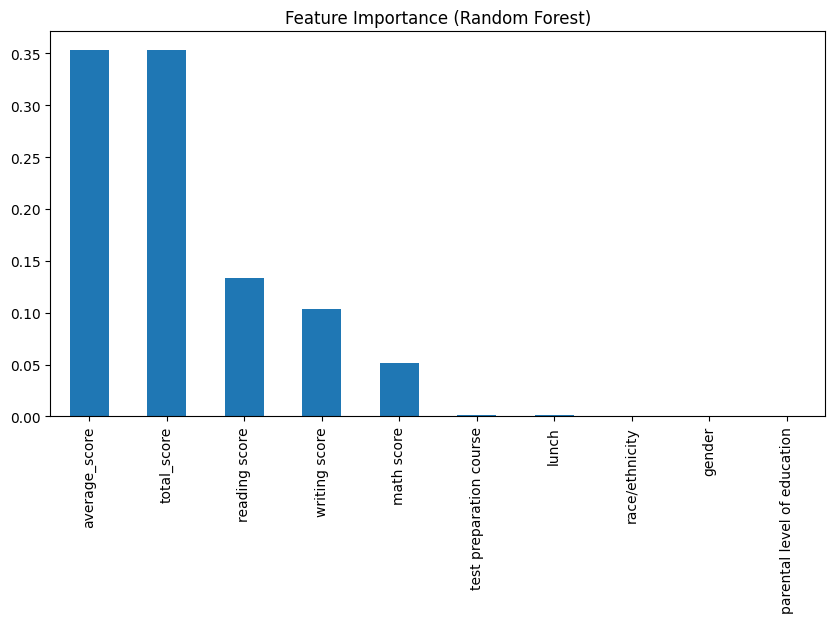

In [33]:
# Feature Importance (Random Forest)

importances = pd.Series(rf.feature_importances_, index=X_clf.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

## 12. SHAP Interpretation

SHAP (SHapley Additive explanations) is used to interpret the predictions of the Gradient Boosting model.

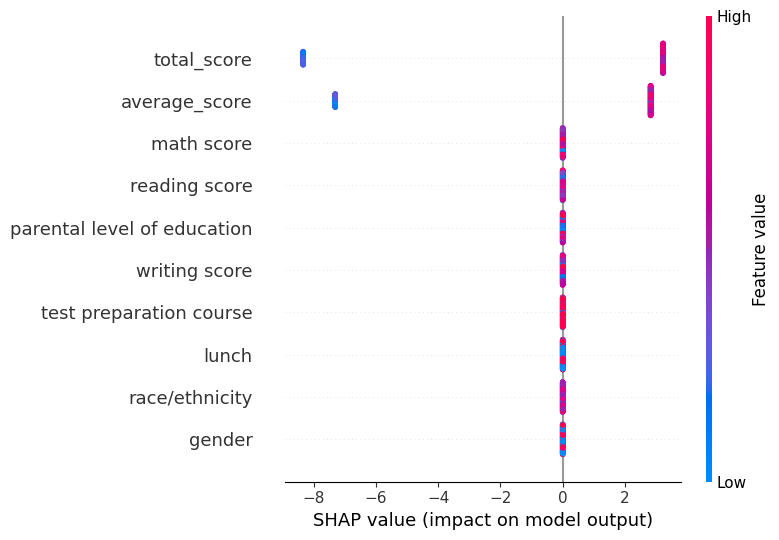

In [34]:
# Shap Interpretation

import shap

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test_clf)

shap.summary_plot(shap_values, X_test_clf)